# Data Processing Suite Tests

A few tests to verify whether the data processing suite functions as intended. Data are generated here and loaded into the sim GUI. Results from data processing operations are compared to the methods used below for validation. 

In [3]:
# Imports

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Initial Dataset Creation

In [4]:
# Some arbitrary unix posix start time
t0 = 1_700_000_000

# Dataset 1: starts earlier, 1-second sampling
t1 = np.arange(t0, t0 + 600, 1)
df1 = pd.DataFrame({
    "posix_time": t1,
    "sinewave": 2.0 * np.sin(2 * np.pi * (t1 - t1[0]) / 60)
})

# Dataset 2: starts later but ends later, 2-second sampling (used to vallidate whether merging cuts of tails)
t2 = np.arange(t0 + 30, t0 + 660, 2)
df2 = pd.DataFrame({
    "posix_time": t2,
    "sinewave": 5.0 * np.sin(2 * np.pi * (t2 - t2[0]) / 120)
})

df1.to_csv("data/sinewave_1sec.csv", index=False)
df2.to_csv("data/sinewave_2sec.csv", index=False)

In [8]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   posix_time  600 non-null    int32  
 1   sinewave    600 non-null    float64
dtypes: float64(1), int32(1)
memory usage: 7.2 KB


In [9]:
df1.describe()

,posix_time,sinewave
count,6.000000e+02,6.000000e+02
mean,1.700000e+09,-2.960595e-17
std,1.733494e+02,1.415394e+00
min,1.700000e+09,-2.000000e+00
25%,1.700000e+09,-1.375268e+00
50%,1.700000e+09,-1.867896e-15
75%,1.700000e+09,1.375268e+00
max,1.700001e+09,2.000000e+00


In [10]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 315 entries, 0 to 314
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   posix_time  315 non-null    int32  
 1   sinewave    315 non-null    float64
dtypes: float64(1), int32(1)
memory usage: 3.8 KB


In [11]:
df2.describe()

,posix_time,sinewave
count,3.150000e+02,315.000000
mean,1.700000e+09,0.143501
std,1.821538e+02,3.532611
min,1.700000e+09,-5.000000
25%,1.700000e+09,-3.345653
50%,1.700000e+09,0.522642
75%,1.700001e+09,3.715724
max,1.700001e+09,5.000000


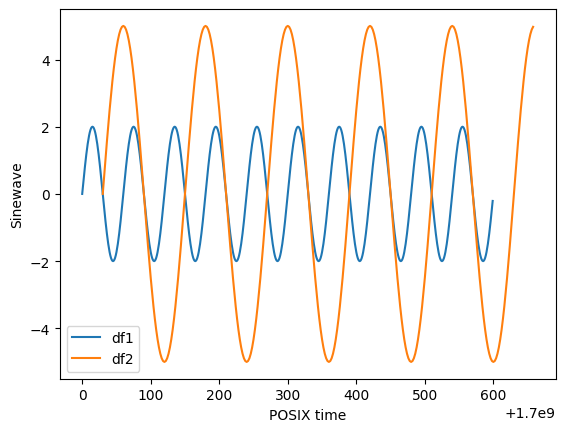

In [5]:
plt.plot(df1["posix_time"], df1["sinewave"], label="df1")
plt.plot(df2["posix_time"], df2["sinewave"], label="df2")
plt.xlabel("POSIX time")
plt.ylabel("Sinewave")
plt.legend()
plt.show()

### Load data from GUI output

The following operations were performed on the two datasets created above:
 - Derivative of sinewave
 - Rolling extremal difference (REXD) of sinewave (window sizes 25 and 50)
 - Rolling anchored-range difference (RAD) of sinewave (window sizes 25 and 50)
 - Rolling standard deviation (RSTDEV) of sinewave (window sizes 25 and 50)
 - Rolling variance (RVAR) of sinewave (window sizes 25 and 50)
 - Polynomial expansion of sinewave (2nd and 3rd order)

Datasets are merged on import, so all observations with NaNs are automatically removed after merging.

In [6]:
df = pd.read_csv("data/gui_export.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 285 entries, 0 to 284
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   posix_time           285 non-null    float64
 1   sinewave             285 non-null    float64
 2   sinewave_2           285 non-null    float64
 3   sinewave_derivative  284 non-null    float64
 4   sinewave_rexd_25     285 non-null    float64
 5   sinewave_rad_25      261 non-null    float64
 6   sinewave_rstdev_25   284 non-null    float64
 7   sinewave_rvar_25     284 non-null    float64
 8   sinewave_rexd_50     285 non-null    float64
 9   sinewave_rad_50      236 non-null    float64
 10  sinewave_rstdev_50   284 non-null    float64
 11  sinewave_rvar_50     284 non-null    float64
 12  sinewave^2           285 non-null    float64
 13  poly_sinewave^2_3    285 non-null    float64
 14  sinewave^3           285 non-null    float64
dtypes: float64(15)
memory usage: 33.5 KB


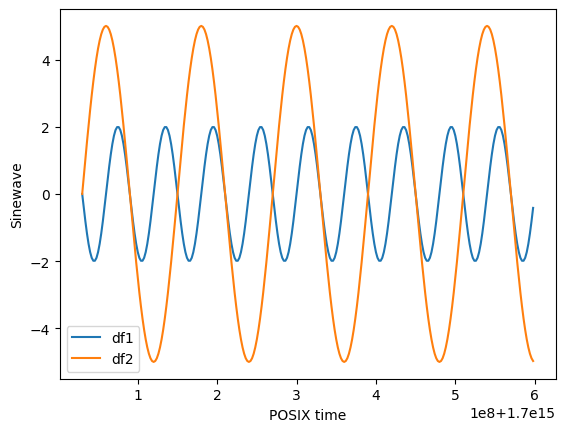

In [7]:
# Plot both sinewaves after import
plt.plot(df["posix_time"], df["sinewave"], label="df1")
plt.plot(df["posix_time"], df["sinewave_2"], label="df2")
plt.xlabel("POSIX time")
plt.ylabel("Sinewave")
plt.legend()
plt.show()

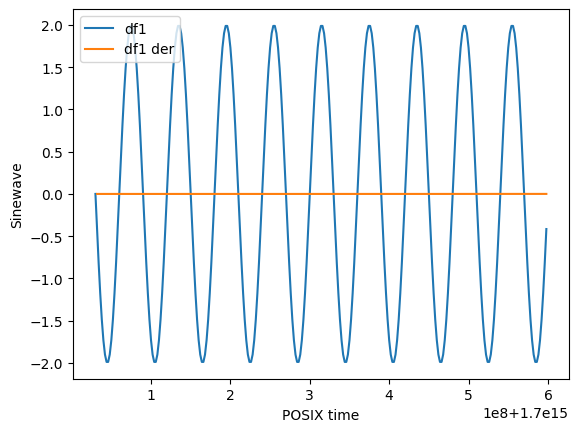

In [12]:
# Sinewave vs derivative
plt.plot(df["posix_time"], df["sinewave"], label="df1")
plt.plot(df["posix_time"], df["sinewave_derivative"], label="df1 der")
plt.xlabel("POSIX time")
plt.ylabel("Sinewave")
plt.legend()
plt.show()